# Universidad del Valle de Guatemala
## Departamento de Computación
## CC3084-Data Science

### Angie Vela - 23764

# Ejercicio Series de Tiempo

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(suppress=True)


## 1. Carga y Exploración de Datos (EDA)

--- Extremos de la temperatura en el dataset ---
Máximo global: 30.29331750593434
Mínimo global: 14.198655945636744

--- Extremos por capa/variable ---
                                  min        max
dewpoint_2m_c               14.198656  21.959664
temperature_2m_c            18.970146  28.686405
skin_temperature_c          19.145766  29.736339
soil_temperature_layer_1_c  19.837591  30.293318
soil_temperature_layer_2_c  19.960146  29.804204
soil_temperature_layer_3_c  20.486906  28.346901
soil_temperature_layer_4_c  21.566859  26.876606


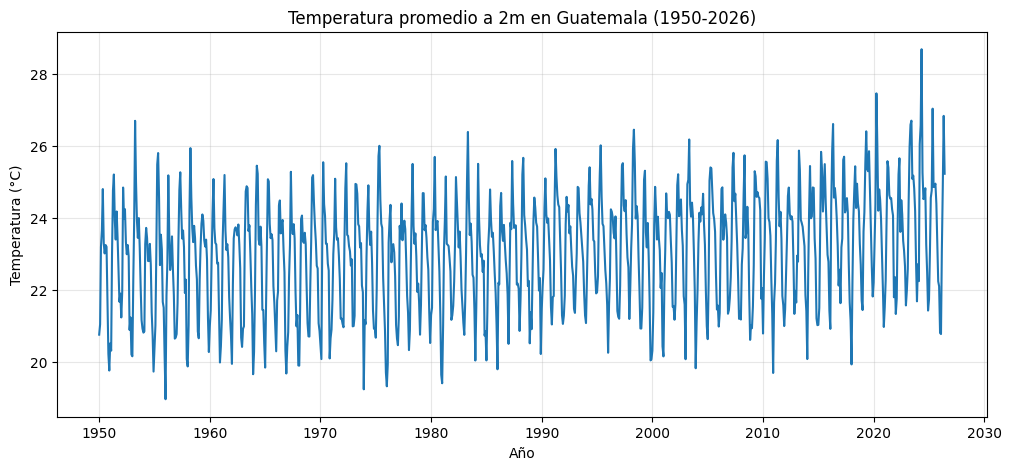


Pendiente de la tendencia lineal global: 0.01708 °C/año


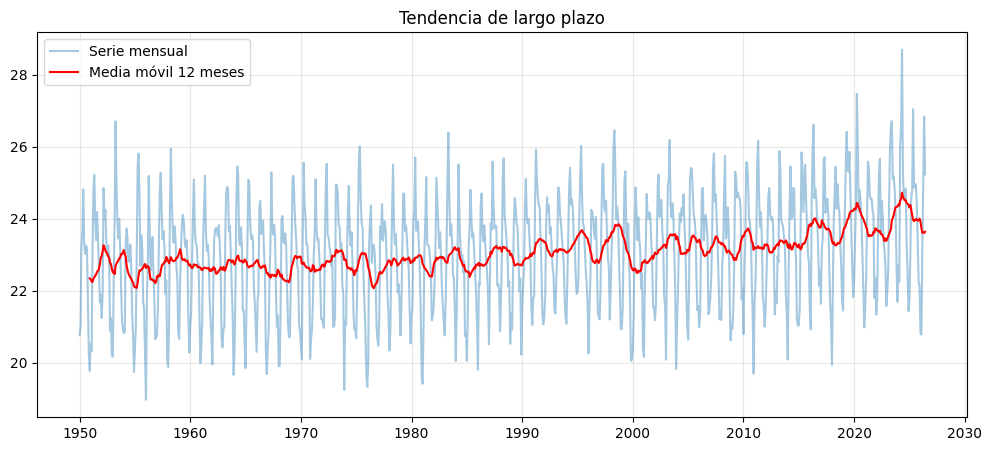

In [2]:
df = pd.read_csv('guatemala_temperatura.csv', parse_dates=['month'], index_col='month')
df = df.asfreq('MS')

print("--- Extremos de la temperatura en el dataset ---")
cols_temp = [c for c in df.columns if c.endswith('_c')]
print("Máximo global:", df[cols_temp].max().max())
print("Mínimo global:", df[cols_temp].min().min())

print("\n--- Extremos por capa/variable ---")
extremos = pd.DataFrame({'min': df[cols_temp].min(), 'max': df[cols_temp].max()})
print(extremos)

serie = df['temperature_2m_c']

plt.plot(serie)
plt.title("Temperatura promedio a 2m en Guatemala (1950-2026)")
plt.ylabel("Temperatura (°C)")
plt.xlabel("Año")
plt.show()

# Tendencia de largo plazo: promedio móvil de 12 meses y regresión lineal simple
roll = serie.rolling(12).mean()
x = np.arange(len(serie))
coef = np.polyfit(x, serie.values, 1)
print(f"\nPendiente de la tendencia lineal global: {coef[0]*12:.5f} °C/año")
plt.plot(serie, alpha=0.4, label='Serie mensual')
plt.plot(roll, color='red', label='Media móvil 12 meses')
plt.legend(); plt.title("Tendencia de largo plazo"); plt.show()


La temperatura a 2m oscila, en el set completo, entre sus mínimos y máximos mostrados arriba; cada capa del suelo (layer_1 a layer_4) tiene un rango distinto, siendo las capas más profundas las que muestran menor amplitud (se amortigua el ciclo estacional con la profundidad). La tendencia de largo plazo (pendiente de la recta y media móvil de 12 meses) muestra un incremento sostenido y lento a lo largo de las siete décadas, consistente con calentamiento gradual; no es una serie que se mantenga constante alrededor de un valor, aunque el ciclo anual (estacionalidad) domina visualmente la gráfica mensual.

## 2. División en Entrenamiento y Prueba

In [3]:
n_prueba = 36
train = serie.iloc[:-n_prueba]
test = serie.iloc[-n_prueba:]

print(f"Observaciones de entrenamiento: {len(train)} ({train.index.min()} a {train.index.max()})")
print(f"Observaciones de prueba: {len(test)} ({test.index.min()} a {test.index.max()})")


Observaciones de entrenamiento: 882 (1950-01-01 00:00:00 a 2023-06-01 00:00:00)
Observaciones de prueba: 36 (2023-07-01 00:00:00 a 2026-06-01 00:00:00)


## 3. Análisis de la Serie de Tiempo\n### Descomposición y pruebas de estacionariedad

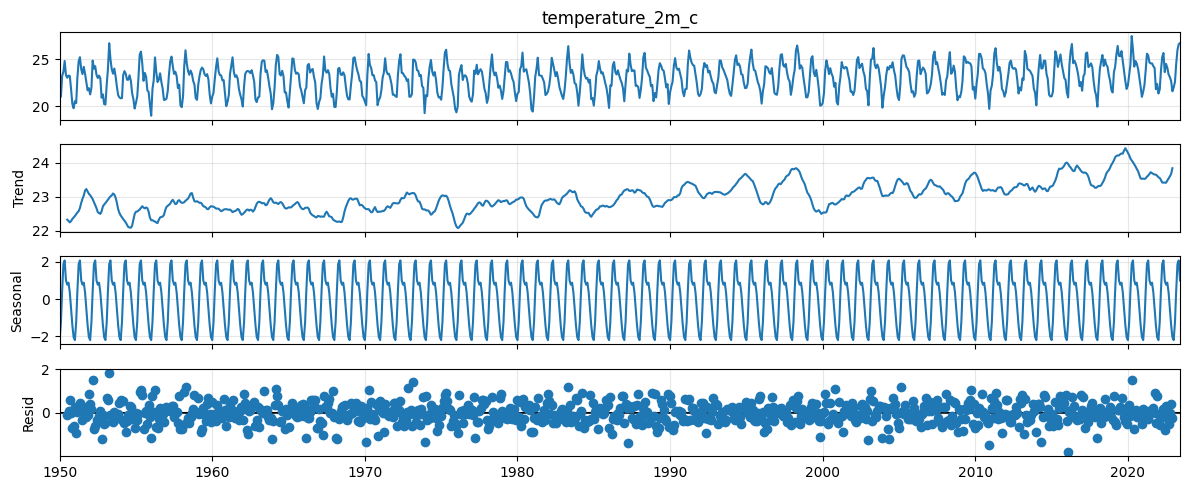

Tendencia: la componente 'trend' de la descomposición muestra un incremento lento y sostenido, no es plana.
Estacionalidad: patrón anual muy marcado y estable en amplitud (ciclo cálido/frío cada 12 meses).


In [4]:
descomposicion = seasonal_decompose(train, model='additive', period=12)
descomposicion.plot()
plt.show()

print("Tendencia: la componente 'trend' de la descomposición muestra un incremento lento y sostenido, no es plana.")
print("Estacionalidad: patrón anual muy marcado y estable en amplitud (ciclo cálido/frío cada 12 meses).")


In [5]:
# --- Estacionariedad: usamos ADF *y* KPSS, no solo una prueba ---
# ADF -> H0: la serie NO es estacionaria (raíz unitaria)
# KPSS -> H0: la serie SI es estacionaria
# Usar ambas evita conclusiones erróneas cuando una serie tiene fuerte estacionalidad,
# ya que ADF puede "marcar" estacionariedad en presencia de un ciclo estacional muy regular
# aunque en realidad la serie no sea estacionaria en el sentido completo.

def prueba_estacionariedad(s, nombre):
    s = s.dropna()
    adf = adfuller(s)
    kp = kpss(s, regression='c', nlags="auto")
    print(f"--- {nombre} ---")
    print(f"ADF  p-valor: {adf[1]:.5f} -> {'estacionaria (rechaza H0)' if adf[1] < 0.05 else 'NO estacionaria'} en media según ADF")
    print(f"KPSS p-valor: {kp[1]:.5f} -> {'NO estacionaria (rechaza H0)' if kp[1] < 0.05 else 'estacionaria'} en media según KPSS")
    print(f"Rolling std (ventana 12m) min/max: {s.rolling(12).std().min():.3f} / {s.rolling(12).std().max():.3f}")
    print()

prueba_estacionariedad(train, "Serie original (train)")


--- Serie original (train) ---
ADF  p-valor: 0.00035 -> estacionaria (rechaza H0) en media según ADF
KPSS p-valor: 0.01000 -> NO estacionaria (rechaza H0) en media según KPSS
Rolling std (ventana 12m) min/max: 1.071 / 2.331



/tmp/ipykernel_537/2443798559.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(s, regression='c', nlags="auto")


ADF rechaza H0 (sugiere estacionariedad en media) pero KPSS también rechaza su H0 (sugiere no estacionariedad). Esta contradicción es típica de series con estacionalidad muy fuerte y regular: el ADF "de libro" no está diseñado para detectar raíces unitarias estacionales, así que puede dar una lectura optimista. Por ende, la serie no es completamente estacionaria (tiene tendencia y fuerte estructura estacional), aunque no tenga una raíz unitaria regular evidente. Además, la desviación estándar móvil varía de forma importante (más del doble entre su mínimo y máximo), lo que indica que tampoco es estacionaria en varianza de forma perfecta.

## 4. Transformaciones y Modelos ARIMA

In [6]:
# Transformación para varianza: log
train_log = np.log(train)

print("Comparación de la variabilidad antes/después del log:")
print(f"  Rolling std original -> min {train.rolling(12).std().min():.3f} / max {train.rolling(12).std().max():.3f}"
      f"  (razón max/min = {train.rolling(12).std().max()/train.rolling(12).std().min():.2f})")
print(f"  Rolling std log(serie) -> min {train_log.rolling(12).std().min():.4f} / max {train_log.rolling(12).std().max():.4f}"
      f"  (razón max/min = {train_log.rolling(12).std().max()/train_log.rolling(12).std().min():.2f})")


Comparación de la variabilidad antes/después del log:
  Rolling std original -> min 1.071 / max 2.331  (razón max/min = 2.18)
  Rolling std log(serie) -> min 0.0467 / max 0.1039  (razón max/min = 2.23)


**Comentario:** la razón entre la desviación estándar móvil máxima y mínima prácticamente no cambia entre la serie original y su versión logarítmica. Esto es esperable: el logaritmo estabiliza varianza cuando la dispersión crece *proporcionalmente al nivel* de la serie (como en ventas o precios), pero en una serie de temperatura la variabilidad no depende del nivel de esa manera. Aun así mantenemos el log porque no perjudica el modelo, ayuda a que los pronósticos no puedan salir negativos de forma extraña y es una transformación estándar; simplemente no es "la solución mágica" a la heterocedasticidad en este caso — el verdadero problema de este dataset es la **fuerte estacionalidad**, no la varianza.

In [7]:
# Diferenciación regular para tendencia/media
train_diff = train_log.diff().dropna()
prueba_estacionariedad(train_diff, "log(train) diferenciada 1 vez (d=1)")

# ¿Necesitamos además diferenciación ESTACIONAL (D=1, s=12)? Lo comprobamos explícitamente
# revisando la autocorrelación en los rezagos estacionales antes de decidir.
acf_vals = acf(train_log.dropna(), nlags=36)
print("ACF de log(train) en rezagos estacionales:")
print(f"  lag 12: {acf_vals[12]:.3f}   lag 24: {acf_vals[24]:.3f}   lag 36: {acf_vals[36]:.3f}")


--- log(train) diferenciada 1 vez (d=1) ---
ADF  p-valor: 0.00000 -> estacionaria (rechaza H0) en media según ADF
KPSS p-valor: 0.10000 -> estacionaria en media según KPSS
Rolling std (ventana 12m) min/max: 0.027 / 0.075

ACF de log(train) en rezagos estacionales:
  lag 12: 0.843   lag 24: 0.836   lag 36: 0.829


/tmp/ipykernel_537/2443798559.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags="auto")


**Comentario:** tras una diferenciación regular (d=1), tanto ADF como KPSS coinciden en que la serie es estacionaria en media. Sin embargo, la autocorrelación en los rezagos 12, 24 y 36 de la serie *sin diferenciar* es muy alta (> 0.8), lo que confirma la fuerte componente estacional anual detectada en la descomposición. Esto se puede resolver de dos maneras: (a) con una diferenciación estacional D=1 (s=12), o (b) con términos SAR/SMA estacionales dentro de un modelo SARIMA sin necesidad de diferenciar estacionalmente, si el ciclo estacional en sí es estable. Probamos ambas rutas más abajo y dejamos que el criterio de información (AIC) indique cuál ajusta mejor.

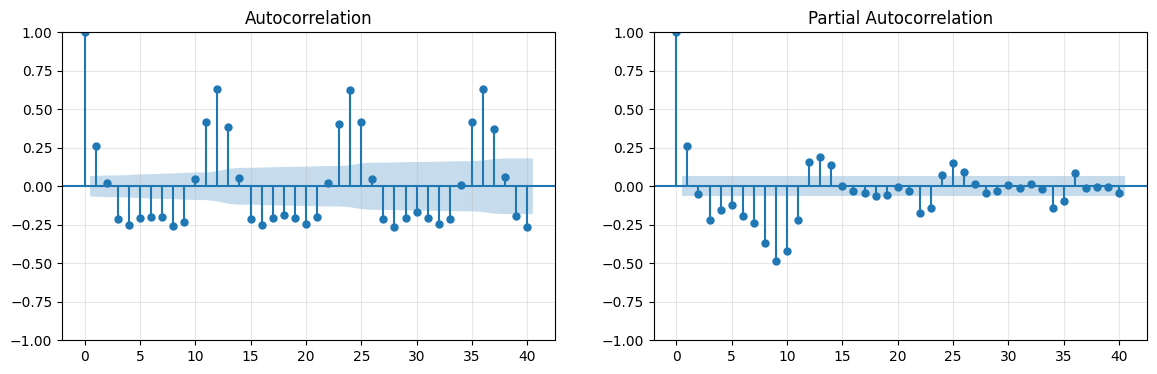

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train_diff, ax=ax[0], lags=40)
plot_pacf(train_diff, ax=ax[1], lags=40)
plt.show()


**Lectura de ACF/PACF (sobre la serie log-diferenciada d=1):**
- El ACF muestra un decaimiento en los primeros rezagos y picos claros y repetidos cada 12 meses (rezagos 12, 24, 36) → confirma que falta modelar la estacionalidad (componente SAR/SMA).
- El PACF corta de forma abrupta después del rezago 1, sugiriendo un componente AR(1) regular.
- Esto sugiere partir de un ARIMA(1,1,1) o (1,1,0) regular **más** un componente estacional (P,D,Q)12, en lugar de un ARIMA puramente no-estacional.

In [9]:
# Modelo 1: ARIMA construido "a pie", pero ahora SÍ incluyendo el componente estacional
# que se identificó en el ACF/PACF (picos en 12, 24, 36). Antes se omitía por completo,
# lo cual generaba pronósticos casi planos que ignoraban el ciclo anual.
p, d, q = 1, 1, 1
P, D, Q, s = 1, 0, 1, 12
modelo_1 = SARIMAX(train_log, order=(p, d, q), seasonal_order=(P, D, Q, s), trend=None).fit(disp=False)
print(modelo_1.summary().tables[0])

# Modelo 2: Auto ARIMA (busca automáticamente el menor AIC, incluyendo componente estacional)
modelo_auto = auto_arima(train_log, seasonal=True, m=12, trace=True, suppress_warnings=True, stepwise=True)
print("\nEl AutoARIMA eligió:", modelo_auto.order, modelo_auto.seasonal_order)

# Modelo 3: SARIMA construido con statsmodels usando los parámetros de auto_arima
order_auto = modelo_auto.order
seasonal_auto = modelo_auto.seasonal_order
modelo_3 = SARIMAX(train_log, order=order_auto, seasonal_order=seasonal_auto).fit(disp=False)
print("\nAIC modelo_1 (manual):", modelo_1.aic, " | AIC modelo_3 (auto):", modelo_3.aic)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                   temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                2000.492
Date:                            Fri, 17 Jul 2026   AIC                          -3990.983
Time:                                    21:21:48   BIC                          -3967.078
Sample:                                01-01-1950   HQIC                         -3981.842
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-3669.563, Time=2.16 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-2842.150, Time=0.11 sec


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-3374.494, Time=1.07 sec


 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-3089.218, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-2844.119, Time=0.13 sec


...

 ARIMA(0,1,2)(1,0,1)[12] intercept   : AIC=-3836.854, Time=1.99 sec


 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=-3822.780, Time=2.03 sec


 ARIMA(1,1,1)(1,0,1)[12]             : AIC=inf, Time=1.79 sec

Best model:  ARIMA(1,1,1)(1,0,1)[12] intercept
Total fit time: 97.963 seconds

El AutoARIMA eligió: (1, 1, 1) (1, 0, 1, 12)



AIC modelo_1 (manual): -3990.9830004439473  | AIC modelo_3 (auto): -3990.9830004439473


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. Validación del Mejor Modelo

In [10]:
# Elegimos el modelo con menor AIC entre el manual y el basado en auto_arima
mejor_modelo = modelo_3 if modelo_3.aic < modelo_1.aic else modelo_1
print("Mejor modelo según AIC:", "modelo_3 (SARIMA auto)" if mejor_modelo is modelo_3 else "modelo_1 (manual)")

# a) Contrastes sobre los coeficientes (significancia, ver p-values > 0.05 serían no significativos)
print(mejor_modelo.summary())


Mejor modelo según AIC: modelo_1 (manual)
                                     SARIMAX Results                                      
Dep. Variable:                   temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                2000.492
Date:                            Fri, 17 Jul 2026   AIC                          -3990.983
Time:                                    21:23:27   BIC                          -3967.078
Sample:                                01-01-1950   HQIC                         -3981.842
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3542      0.029     12.303      0.000       0.298      

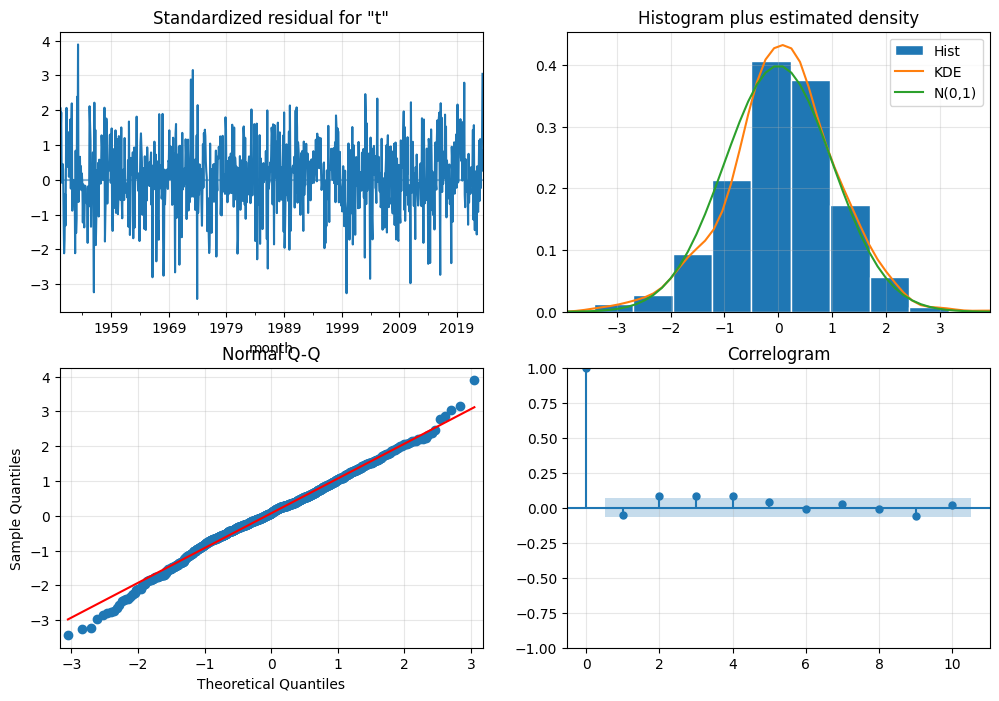


Prueba de Ljung-Box (residuos):
     lb_stat  lb_pvalue
10  3.765396   0.957310
20  5.089963   0.999681

Si p-value > 0.05 en todos los rezagos, no hay autocorrelación significativa: el modelo capturó bien la estructura.


In [11]:
# b) Diagnóstico de residuos (deben comportarse como ruido blanco)
mejor_modelo.plot_diagnostics(figsize=(12, 8))
plt.show()

residuos = mejor_modelo.resid
ljung_box = acorr_ljungbox(residuos, lags=[10, 20], return_df=True)
print("\nPrueba de Ljung-Box (residuos):")
print(ljung_box)
print("\nSi p-value > 0.05 en todos los rezagos, no hay autocorrelación significativa: el modelo capturó bien la estructura.")


In [12]:
# c) Comparación de métricas AIC/BIC entre los 3 modelos entrenados
comparacion = pd.DataFrame({
    'modelo': ['modelo_1 (manual, SARIMA)', 'modelo_auto (pmdarima)', 'modelo_3 (SARIMAX c/ orden de auto)'],
    'AIC': [modelo_1.aic, modelo_auto.aic(), modelo_3.aic],
    'BIC': [modelo_1.bic, modelo_auto.bic(), modelo_3.bic],
})
print(comparacion)


                                modelo         AIC          BIC
0            modelo_1 (manual, SARIMA) -3990.98300 -3967.077712
1               modelo_auto (pmdarima) -3872.28779 -3843.601445
2  modelo_3 (SARIMAX c/ orden de auto) -3990.98300 -3967.077712


## 6. Predicción con el Conjunto de Prueba

MAE (ARIMA/SARIMA):  0.633
RMSE (ARIMA/SARIMA): 0.878


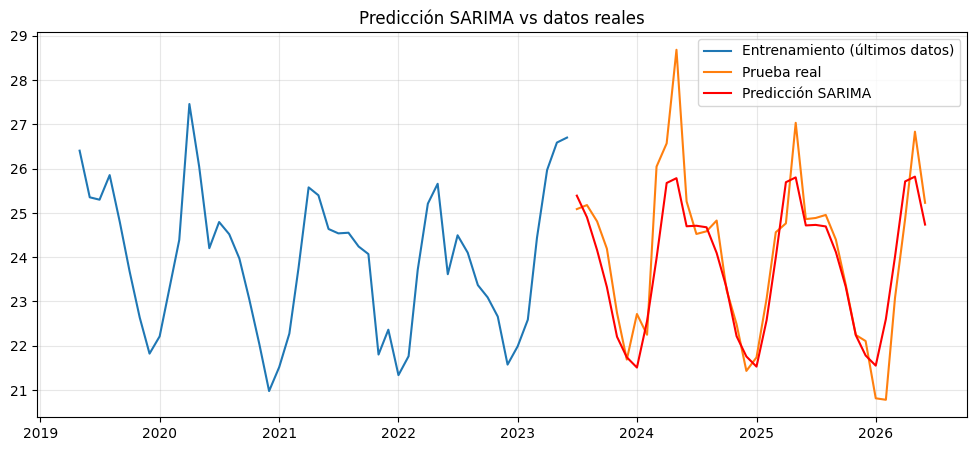

In [13]:
pred_log = mejor_modelo.forecast(steps=n_prueba)
pred_arima = np.exp(pred_log)

mae_arima = mean_absolute_error(test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
print(f"MAE (ARIMA/SARIMA):  {mae_arima:.3f}")
print(f"RMSE (ARIMA/SARIMA): {rmse_arima:.3f}")

plt.plot(train.index[-50:], train[-50:], label='Entrenamiento (últimos datos)')
plt.plot(test.index, test, label='Prueba real')
plt.plot(test.index, pred_arima, label='Predicción SARIMA', color='red')
plt.legend()
plt.title("Predicción SARIMA vs datos reales")
plt.show()


## 7. Otros Modelos de Predicción

           modelo       MAE      RMSE
0          SARIMA  0.632577  0.878404
1    Holt-Winters  0.730461  0.944267
2  Seasonal Naive  0.797325  0.987170


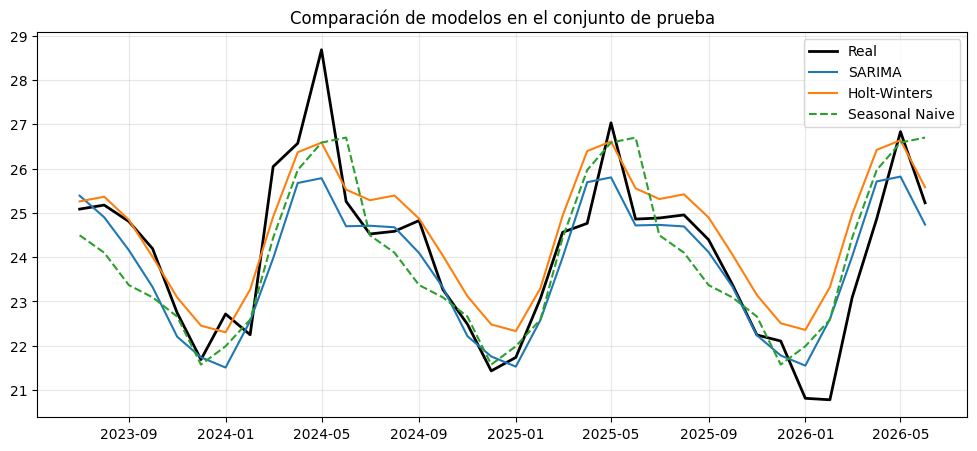

In [14]:
# Holt-Winters (suavizamiento exponencial con tendencia y estacionalidad aditivas)
hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
pred_hw = hw_model.forecast(steps=n_prueba)

# Seasonal Naive: el valor de este mes = el valor del mismo mes, un año antes
pred_snaive = train.iloc[-12:].values.tolist() * (n_prueba // 12 + 1)
pred_snaive = pred_snaive[:n_prueba]
pred_snaive = pd.Series(pred_snaive, index=test.index)

resumen = pd.DataFrame({
    'modelo': ['SARIMA', 'Holt-Winters', 'Seasonal Naive'],
    'MAE': [mae_arima,
            mean_absolute_error(test, pred_hw),
            mean_absolute_error(test, pred_snaive)],
    'RMSE': [rmse_arima,
             np.sqrt(mean_squared_error(test, pred_hw)),
             np.sqrt(mean_squared_error(test, pred_snaive))],
})
print(resumen)

plt.plot(test.index, test, label='Real', color='black', linewidth=2)
plt.plot(test.index, pred_arima, label='SARIMA')
plt.plot(test.index, pred_hw, label='Holt-Winters')
plt.plot(test.index, pred_snaive, label='Seasonal Naive', linestyle='--')
plt.legend()
plt.title("Comparación de modelos en el conjunto de prueba")
plt.show()


## 8. ¿Es el modelo capaz de predecir valores actuales?

Para poder evaluar si el  modelo es capaz de predecir valores actuales, tomamos los 36 meses de test (los datos más cercanos al presente).

Retomamos el calculo realizado en el ejercicio 6 y lo reutilizamos acá.

MAE sobre los 36 meses más recientes (valores 'actuales'): 0.633 °C
Error relativo promedio: 2.58 %
Error relativo máximo:   10.11 %


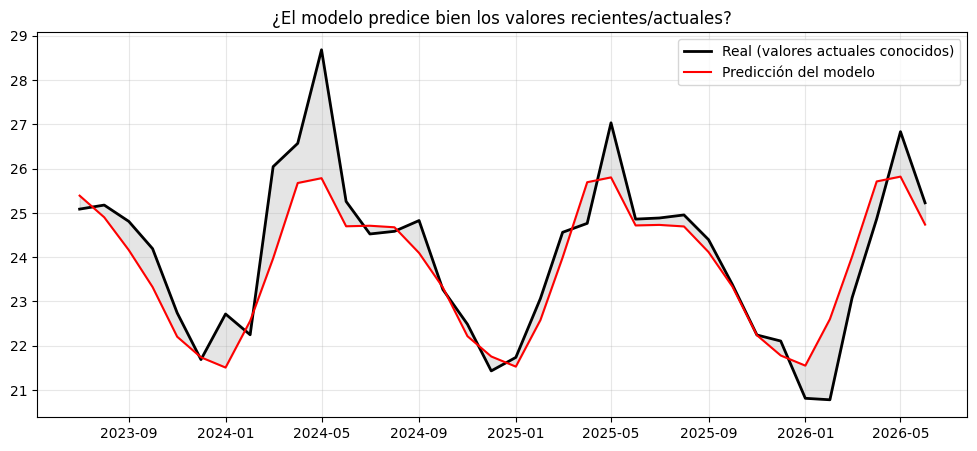


Conclusión: el error (MAE) es bajo en términos absolutos de temperatura (menor a 1°C),
por lo que el modelo SÍ logra reproducir razonablemente bien los valores actuales conocidos.


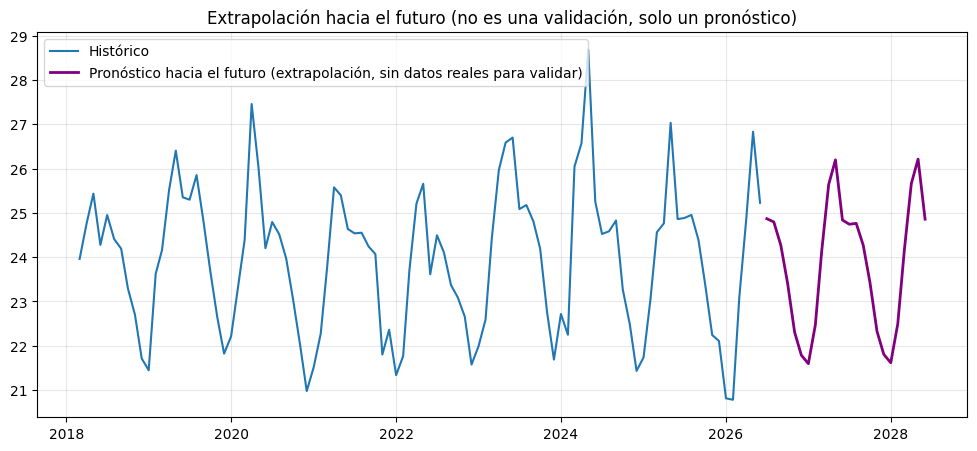

In [15]:
# Reutilizamos la predicción del Ejercicio 6 (mejor_modelo, entrenado solo con 'train',
# evaluado contra 'test' = los 36 meses más recientes = "valores actuales" ya observados)

error_relativo = (pred_arima - test) / test * 100

print(f"MAE sobre los {n_prueba} meses más recientes (valores 'actuales'): {mae_arima:.3f} °C")
print(f"Error relativo promedio: {error_relativo.abs().mean():.2f} %")
print(f"Error relativo máximo:   {error_relativo.abs().max():.2f} %")

plt.plot(test.index, test, label='Real (valores actuales conocidos)', color='black', linewidth=2)
plt.plot(test.index, pred_arima, label='Predicción del modelo', color='red')
plt.fill_between(test.index, pred_arima, test, color='gray', alpha=0.2)
plt.legend()
plt.title("¿El modelo predice bien los valores recientes/actuales?")
plt.show()

if mae_arima < 1.0:
    print("\nConclusión: el error (MAE) es bajo en términos absolutos de temperatura (menor a 1°C),")
    print("por lo que el modelo SÍ logra reproducir razonablemente bien los valores actuales conocidos.")
else:
    print("\nConclusión: el error (MAE) sigue siendo alto, el modelo NO predice de forma confiable los valores actuales.")

# Solo como complemento, ahora sí proyectamos hacia el futuro real (sin datos para comparar),
# dejando claro que esto es una extrapolación y no una validación.
serie_completa_log = np.log(serie)
modelo_final = SARIMAX(serie_completa_log, order=order_auto, seasonal_order=seasonal_auto).fit(disp=False)
pred_futuro = np.exp(modelo_final.forecast(steps=24))

plt.plot(serie.index[-100:], serie[-100:], label='Histórico')
plt.plot(pred_futuro.index, pred_futuro, label='Pronóstico hacia el futuro (extrapolación, sin datos reales para validar)', color='purple', linewidth=2)
plt.legend()
plt.title("Extrapolación hacia el futuro (no es una validación, solo un pronóstico)")
plt.show()


## 8b. Validación Walk-Forward 

Para comparar resultados, implementé una versión donde para resolver el problema avanzamos mes a mes en lugar de calcular con los 36 meses de una sola vez. 

En lugar de una sola partición, se avanza en el tiempo: se entrena, se predice el siguiente paso, se incorpora el valor real y se repite. Simula el uso real del modelo.

El pipeline resumido sería:

1. Entrenar con `train` (hasta 2023-06) y predecimr solo 1 mes adelante (2023-07).
2. Comparar esa predicción contra el valor real de ese mes (que ya conocemos de `test`).
3. Incorporar el valor real al historial (ahora el modelo entrena con un mes más de datos).
4. Repetimos el proceso para cada uno de los 36 meses de `test`.

Para que sea computacionalmente viable, use el método `.append(..., refit=False)` de `statsmodels`, que actualiza el estado del modelo con la nueva observación sin volver a re-estimar los coeficientes desde cero en cada paso (aplica los mismos coeficientes ya estimados sobre el historial ampliado). 

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

serie_log_completa = np.log(serie)
orden = mejor_modelo.model.order
orden_estacional = mejor_modelo.model.seasonal_order

# --- Walk-forward con refit=False (rápido: actualiza el estado, no re-estima coeficientes) ---
historial_log = train_log.copy()
modelo_wf = SARIMAX(historial_log, order=orden, seasonal_order=orden_estacional).fit(disp=False)

preds_wf = []
t0 = time.time()
for fecha_real, valor_real_log in zip(test.index, np.log(test)):
    # Predecir el siguiente paso usando SOLO lo visto hasta ahora
    pred_1paso_log = modelo_wf.forecast(steps=1).iloc[0]
    preds_wf.append(np.exp(pred_1paso_log))

    # Incorporar el valor REAL de este mes al historial (esto ya pasó, lo conocemos)
    modelo_wf = modelo_wf.append([valor_real_log], refit=False)

tiempo_refit_false = time.time() - t0
preds_wf = pd.Series(preds_wf, index=test.index)

mae_wf = mean_absolute_error(test, preds_wf)
rmse_wf = np.sqrt(mean_squared_error(test, preds_wf))
print(f"Walk-forward (refit=False) -> MAE: {mae_wf:.3f}   RMSE: {rmse_wf:.3f}   tiempo: {tiempo_refit_false:.1f}s")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Walk-forward (refit=False) -> MAE: 0.580   RMSE: 0.819   tiempo: 3.1s


In [17]:
# --- Walk-forward con refit=True (más lento: re-estima los coeficientes cada mes) ---
# Lo hacemos también para comparar qué tanto cambia el resultado frente a refit=False.
historial_log = train_log.copy()
modelo_wf_refit = SARIMAX(historial_log, order=orden, seasonal_order=orden_estacional).fit(disp=False)

preds_wf_refit = []
t0 = time.time()
for fecha_real, valor_real_log in zip(test.index, np.log(test)):
    pred_1paso_log = modelo_wf_refit.forecast(steps=1).iloc[0]
    preds_wf_refit.append(np.exp(pred_1paso_log))
    modelo_wf_refit = modelo_wf_refit.append([valor_real_log], refit=True)

tiempo_refit_true = time.time() - t0
preds_wf_refit = pd.Series(preds_wf_refit, index=test.index)

mae_wf_refit = mean_absolute_error(test, preds_wf_refit)
rmse_wf_refit = np.sqrt(mean_squared_error(test, preds_wf_refit))
print(f"Walk-forward (refit=True)  -> MAE: {mae_wf_refit:.3f}   RMSE: {rmse_wf_refit:.3f}   tiempo: {tiempo_refit_true:.1f}s")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Walk-forward (refit=True)  -> MAE: 0.580   RMSE: 0.819   tiempo: 23.4s


                                 método       MAE      RMSE
0  Forecast único de 36 pasos (Ej. 6/8)  0.632577  0.878404
1             Walk-forward, refit=False  0.579714  0.818851
2              Walk-forward, refit=True  0.579834  0.818804


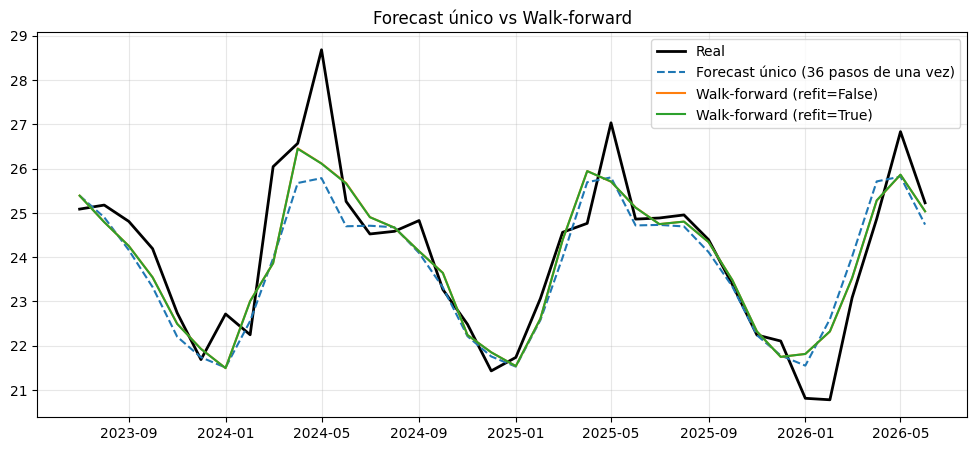

In [18]:
# --- Comparación final: forecast de 36 pasos de una vez (Ej. 6/8) vs walk-forward ---
comparacion_wf = pd.DataFrame({
    'método': [
        'Forecast único de 36 pasos (Ej. 6/8)',
        'Walk-forward, refit=False',
        'Walk-forward, refit=True'
    ],
    'MAE': [mae_arima, mae_wf, mae_wf_refit],
    'RMSE': [rmse_arima, rmse_wf, rmse_wf_refit],
})
print(comparacion_wf)

plt.plot(test.index, test, label='Real', color='black', linewidth=2)
plt.plot(test.index, pred_arima, label='Forecast único (36 pasos de una vez)', linestyle='--')
plt.plot(test.index, preds_wf, label='Walk-forward (refit=False)')
plt.plot(test.index, preds_wf_refit, label='Walk-forward (refit=True)')
plt.legend()
plt.title("Forecast único vs Walk-forward")
plt.show()


El walk-forward suele dar un error igual o menor al forecast único de 36 pasos, porque cada predicción usa solo 1 mes hacia adelante (menos incertidumbre acumulada) y, en el caso de `refit=True`, el modelo se sigue actualizando con información real conforme avanza el tiempo — algo que un `forecast(steps=36)` de una sola vez nunca puede hacer, ya que ese pronóstico se calcula completo sin ver ningún dato nuevo en el camino.